In [1]:
import os

# in the case of a workstation with multiple GPU devices
# we can select only one of them for use in this notebook
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Variational Autoencoder with a Normalizing Flow prior

Using a normalizing flow as prior for the latent variables instead of the typical standard Gaussian is an easy way to make a variational autoencoder (VAE) more expressive. This notebook demonstrates how to implement a VAE with a normalizing flow as prior for the MNIST dataset. We strongly recommend to read [Pyro's VAE tutorial](vae.ipynb) first.

> In this notebook we use [Zuko](https://zuko.readthedocs.io/) to implement normalizing flows, but similar results can be obtained with other PyTorch-based flow libraries.

In [2]:
import pyro
import torch
import torch.nn as nn
import torch.utils.data as data
import zuko

from pyro.contrib.zuko import ZukoToPyro
from pyro.optim import AdamW
from pyro.infer import SVI, Trace_ELBO
from torch import Tensor
from torchvision.datasets import MNIST
from torchvision.transforms.functional import to_tensor, to_pil_image
from torch.nn.functional import relu, sigmoid, softplus, grid_sample, affine_grid, one_hot, softmax, pad
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
from mlp_mixer_pytorch import MLPMixer

sns.set_theme(context='notebook', style='dark', palette='deep', font='sans-serif', font_scale=1, color_codes=True)
plt.style.use('dark_background')

## Data

The [MNIST](https://wikipedia.org/wiki/MNIST_database) dataset consists of 28 x 28 grayscale images representing handwritten digits (0 to 9).

In [3]:
trainset = MNIST(root='data', download=True, train=True, transform=to_tensor)
testset = MNIST(root='data', download=True, train=False, transform=to_tensor)
batch_size = 256
trainloader = data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = data.DataLoader(testset, batch_size=128, shuffle=True)

In [4]:
x = [trainset[i][0] for i in range(8)]
x = torch.cat(x, dim=-1)

to_pil_image(x)

In [5]:
grid_x, grid_y = torch.meshgrid(torch.arange(28), torch.arange(28), indexing='ij')

grid = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=-1)

def image_to_pointcloud(x, num_samples=100):
    pixel_args = torch.multinomial(x, num_samples, replacement=True)
    locs = grid[pixel_args] + torch.rand(len(x), num_samples, 2)
    return 2 * torch.cat([locs / 28, torch.take_along_dim(x, pixel_args, dim=1)[..., None]], dim=-1) - 1

x = [trainset[i][0].reshape(-1) for i in range(8)]
x = torch.stack(x)
pointcloud = image_to_pointcloud(x, num_samples=256)

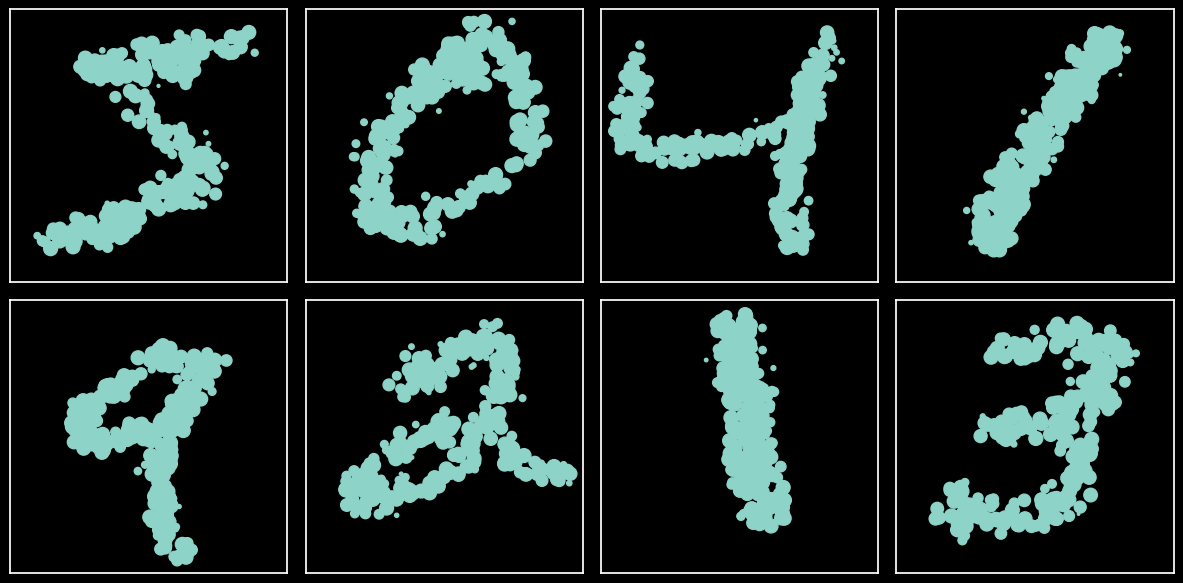

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    ax.scatter(pointcloud[i, :, 1], -pointcloud[i, :, 0], s=100*(pointcloud[i, :, 2] + 1)/2)
    ax.set_yticks([])
    ax.set_xticks([])

fig.tight_layout()

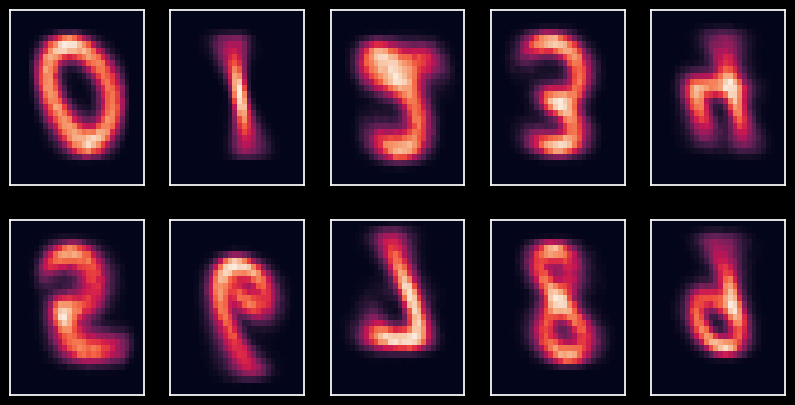

In [7]:
xs = []
ls = []
for x, l in trainloader:
    pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=32)
    xs.append(pointcloud)
    ls.append(l)

xs = torch.cat(xs, dim=0)
ls = torch.cat(ls, dim=-1)

fig, axes = plt.subplots(2, 5, figsize=(10, 5), sharex=True, sharey=True)
for i, ax in enumerate(axes.flatten()):
    loc = ls == i
    ax.hist2d(xs[loc, :, 1].flatten(), xs[loc, :, 0].flatten(), bins=28, range=((-1, 1), (-1, 1)))
    ax.set_yticks([])
    ax.set_xticks([])

## Model

As for the [previous tutorial](vae.ipynb), we choose a (diagonal) Gaussian model as encoder $q_\psi(z | x)$ and a Bernoulli model as decoder $p_\phi(x | z)$. 

In [8]:
class GaussianEncoder(nn.Module):
    def __init__(self, features: int, latent: int, hidden: int = 1024):
        super().__init__()

        self.hyper = nn.Sequential(
            nn.Linear(features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * latent),
        )

    def forward(self, x: Tensor):
        phi = self.hyper(x)
        mu, log_sigma = phi.chunk(2, dim=-1)

        return pyro.distributions.Normal(mu, softplus(log_sigma)).to_event(1)

However, we choose a [masked autoregressive flow](https://arxiv.org/abs/1705.07057) (MAF) as prior $p_\phi(z)$ instead of the typical standard Gaussian $\mathcal{N}(0, I)$. Instead of implementing the MAF ourselves, we borrow it from the [Zuko](https://github.com/probabilists/zuko) library. Because Zuko distributions are very similar to Pyro distributions, a thin wrapper (`ZukoToPyro`) is sufficient to make Zuko and Pyro 100% compatible.

In [12]:
z_where_prior_loc = torch.tensor([1., 0., 0., 0.]).cuda()
z_where_prior_scale = torch.tensor([0.1, 1., 1., 1.]).cuda()
q_scale = torch.tensor([-2., -2., 2., -2.]).cuda()
select_indices = torch.LongTensor([1, 0, 0, 1]).cuda()

def get_test_accuracy(model, num_samples=256):
    comps = []
    for x, l in testloader:
        log_evidence = []
        pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
        for c in one_hot(torch.arange(10), 10).cuda().float():
            with torch.no_grad():
                log_prob = model.log_prob(pointcloud, c[None]).cpu()
                log_evidence.append(log_prob)
        prob = softmax(torch.stack(log_evidence, dim=-1), dim=-1)
        comps.append(prob.argmax(-1) == l)

    return torch.cat(comps).numpy().mean()

def get_test_accuracy2(model, num_samples=256):
    comps = []
    for x, l in testloader:
        log_evidence = []
        pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
        for c in one_hot(torch.arange(10), 10).cuda().float():
            with torch.no_grad():
                log_prob = model.log_prob(pointcloud, c).cpu().sum(-1)
                log_evidence.append(log_prob)
        prob = softmax(torch.stack(log_evidence, dim=-1), dim=-1)
        comps.append(prob.argmax(-1) == l)

    return torch.cat(comps).numpy().mean()

def map_to_sR(q):
    n, k = q.shape
    s = torch.sum(q ** 2, -1, keepdims=True)

    qs = q * q[..., -1:]
    Q = (qs[:, select_indices] * q_scale).view(n, k, k)
    return torch.diag_embed(torch.tile(s, (1, 2))) + Q

def expand_z_where(z_where):
    # Takes 3-dimensional vectors, and massages them into 2x3 matrices with elements like so:
    # [q1, q2 x,y] -> [[s+q11,q12,x], [q21,s + q22,y]] where q11=q22= -2q2^2, q12 = -q21 = -2q1q2.
    n = z_where.size(0)
    sR = map_to_sR(z_where[..., :2])
    return torch.cat((sR, z_where[..., 2:][..., None]), -1)

def object_to_image(z_where, obj, img_size=28, obj_size=28):
    n = obj.size(0)
    theta = expand_z_where(z_where)
    grid = affine_grid(theta, torch.Size((n, 1, img_size, img_size)), align_corners=False)
    out = grid_sample(obj.view(n, 1, obj_size, obj_size), grid, align_corners=False)
    return out.view(n, img_size, img_size)

class Logits(nn.Module):
    def __init__(self, dim1, dim2):
        super().__init__()
        self.logits = nn.Parameter(torch.randn(dim1, dim2) / 10)

    def forward(self, context: Tensor):
        logits = softmax(self.logits, dim=-1).log()
        return context @ logits

# class NFMixtureLikelihood(nn.Module):
#     def __init__(self, latent: int = 3, context: int = 0, num_components: int = 1):
#         super().__init__()

#         self.decoder = nn.ModuleList([
#             zuko.flows.MAF(
#                 features=latent,
#                 context=context,
#                 transforms=3,
#                 hidden_features=(32, 32),
#             ) for c in range(num_components)
#         ])

#         self.logits = Logits(context, num_components - 1)

#     def model(self, x: Tensor, context: Tensor):
#         n, s = x.shape[:2]
#         pyro.module('logits', self.logits)
#         with pyro.plate('batch', n):
#             pyro.factor('x', self.log_prob(x, context).mean(-1) )

#     def guide(self, x: Tensor, context: Tensor):
#         pass

#     def sample(self, context: Tensor, num_samples: int = 1):

#         prob = softmax(self.logits(context), dim=-1)
#         components = torch.multinomial(prob, num_samples, replacement=True)

#         comp_samples = []
#         for i in torch.unique(components):
#             num_samples = torch.sum(i == components).item()
#             comp_samples.append(self.decoder[i](context).sample((num_samples,)))

#         return torch.cat(comp_samples, dim=0)

#     def log_prob(self, x: Tensor, context: Tensor):
#         log_prob = []
#         for i, decoder in enumerate(self.decoder):
#             pyro.module(f"decoder{i}", decoder)
#             log_prob.append(decoder(context).log_prob(x))
        
#         logits = self.logits(context)
#         log_prob = torch.stack(log_prob, -1) + logits

#         return torch.logsumexp(log_prob, -1)

class NFMixtureLikelihood(nn.Module):
    def __init__(self, latent: int = 3, context: int = 0, num_components: int = 1):
        super().__init__()

        self.decoder = zuko.flows.MAF(
                features=latent,
                context=num_components + context,
                transforms=3,
                hidden_features=(256, 256),
            )

        self.logits = Logits(context, num_components)
        self.comp = torch.eye(num_components).cuda().view(num_components, 1, 1, num_components)

    def model(self, x: Tensor, context: Tensor):
        n, s = x.shape[:2]
        pyro.module('logits', self.logits)
        pyro.module('decoder', self.decoder)
        with pyro.plate('batch', n):
            pyro.factor('x', self.log_prob(x, context) )

    def guide(self, x: Tensor, context: Tensor):
        pass

    def sample(self, context: Tensor, num_samples: int = 1):

        prob = softmax(self.logits(context), dim=-1)
        components = torch.multinomial(prob, num_samples, replacement=True)

        comp_samples = []
        for i in torch.unique(components):
            ns = torch.sum(i == components).item()
            c = torch.cat([self.comp[i], context[None, None]], -1)
            comp_samples.append(self.decoder(c).sample((ns,)))

        return torch.cat(comp_samples, dim=0)

    def log_prob(self, x: Tensor, context: Tensor):
        x = torch.broadcast_to(x, self.comp.shape[:1] + x.shape)
        shape = torch.broadcast_shapes(self.comp.shape[:-1], context.shape[:-1])
        comp = torch.broadcast_to(self.comp, shape + self.comp.shape[-1:])
        c = torch.cat([comp, torch.broadcast_to(context, shape + context.shape[-1:])], -1)
        log_prob = self.decoder(c).log_prob(x)
        
        logits = self.logits(context)
        log_prob = log_prob.movedim(0, -1) + logits
        return torch.logsumexp(log_prob, -1).sum(-1)


class VAENFML(nn.Module):
    def __init__(self, num_samples, latent: int = 3, context: int = 0, latent_dim: int = 1, num_components: int = 1):
        super().__init__()

        num_features = num_samples * latent + context
        self.encoder_what = GaussianEncoder(num_features, latent_dim)
        
        self.prior = zuko.flows.MAF(
            features=latent_dim,
            context=context,
            transforms=3,
            hidden_features=(64, 64),
        )

        self.decoder = zuko.flows.MAF(
                features=latent,
                context=context + latent_dim + num_components,
                transforms=3,
                hidden_features=(256, 256),
            )

        self.logits = Logits(context, num_components)

        self.comp = torch.eye(num_components).cuda().view(num_components, 1, 1, num_components)


    def model(self, x: Tensor, context: Tensor):
        n, s = x.shape[:2]
        pyro.module('logits', self.logits)
        pyro.module('prior', self.prior)
        pyro.module('decoder', self.decoder)

        with pyro.plate('batch', n):
            z = pyro.sample("z", ZukoToPyro(self.prior(context.squeeze(-2))))
            pyro.factor('x', self.log_prob(x, z, context))

    def guide(self, x: Tensor, context: Tensor):
        pyro.module("encoder_z", self.encoder_what)
        n = len(x)
        with pyro.plate('batch', n):
            inp = torch.cat([x.reshape(n, -1), context.squeeze(-2)], dim=-1)
            pyro.sample("z", self.encoder_what(inp))

    def sample(self, context: Tensor, num_samples: int = 1):
        prob = softmax(self.logits(context), dim=-1)
        nc = prob.shape[-1]
        components = torch.multinomial(prob, num_samples, replacement=True)

        z = self.prior(context).sample()
        c = torch.cat([z, context], dim=-1)

        comp_samples = []
        for i in torch.unique(components):
            num_samples = torch.sum(i == components).item()
            _c = torch.cat([self.comp[i].squeeze((0, 1)), c], -1)
            comp_samples.append(self.decoder(_c).sample((num_samples,)))

        return torch.cat(comp_samples, dim=0)

    def log_prob(self, x: Tensor, z: Tensor, context: Tensor):
        c = torch.cat([z[..., None, :], context], -1)
        x = torch.broadcast_to(x, self.comp.shape[:1] + x.shape)
        shape = torch.broadcast_shapes(self.comp.shape[:-1], c.shape[:-1])
        comp = torch.broadcast_to(self.comp, shape + self.comp.shape[-1:])
        c = torch.cat([comp, torch.broadcast_to(c, shape + c.shape[-1:])], -1)
        log_prob = self.decoder(c).log_prob(x)
        
        logits = self.logits(context)
        log_prob = log_prob.movedim(0, -1) + logits

        return torch.logsumexp(log_prob, -1).sum(-1)

# class VAEST(nn.Module):
#     def __init__(self, features: int, latent: int = 16, context: int = 0, conditional_posterior: bool = True):
#         super().__init__()
        
#         input_dim = features + context if conditional_posterior else features
#         self.encoder_what = GaussianEncoder(input_dim, latent)
#         self.encoder_where = GaussianEncoder(input_dim, 4)
#         self.decoder = ProbDecoder(features, latent)

#         self.prior = zuko.flows.MAF(
#             features=latent,
#             context=context,
#             transforms=3,
#             hidden_features=(256, 256),
#         )

#         self.conditional_posterior = conditional_posterior

#     def model(self, x: Tensor, context: Tensor):
#         n = len(x)
#         pyro.module("prior", self.prior)
#         pyro.module("decoder", self.decoder)

#         with pyro.plate("batch", n):
#             z_where = pyro.sample('z_where', pyro.distributions.Normal(z_where_prior_loc, z_where_prior_scale).to_event(1))
#             z = pyro.sample("z", ZukoToPyro(self.prior(context)))
#             rho = self.decoder(z)
#             y = object_to_image(z_where, rho).view(n, -1)
#             sd = 0.25 * torch.ones_like(x)
#             pyro.sample('obs', pyro.distributions.Normal(y, sd).to_event(1), obs=x)

#     def guide(self, x: Tensor, context: Tensor):
#         pyro.module("encoder_z", self.encoder_what)
#         pyro.module("encoder_w", self.encoder_where)

#         with pyro.plate("batch", len(x)):
#             inp = torch.cat([x, context], dim=-1) if self.conditional_posterior else x
#             z1 = pyro.sample("z", self.encoder_what(inp))
#             z2 = pyro.sample("z_where", self.encoder_where(inp))


nfml = NFMixtureLikelihood(latent=3, context=10, num_components=8).cuda()
num_samples = 256
nfml_vae = VAENFML(num_samples, latent_dim=3, context=10, num_components=2).cuda()
# vae2 = VAE2(latent=3, context=10, num_components=32).cuda()
# vae3 = VAEST(784, 16, context=10).cuda()
# vae4 = VAEST(784, 16, context=10, conditional_posterior=False).cuda()

## Training

We train our VAE with a standard stochastic variational inference (SVI) pipeline. We first investigate the standard setup without spatial transform prior.

100%|██████████| 64/64 [06:04<00:00,  5.70s/it, loss=19.8]


nc=4-acc:  0.7908


100%|██████████| 64/64 [06:21<00:00,  5.97s/it, loss=20.2]


nc=8-acc:  0.808


100%|██████████| 64/64 [07:18<00:00,  6.85s/it, loss=20.1]


nc=16-acc:  0.7788


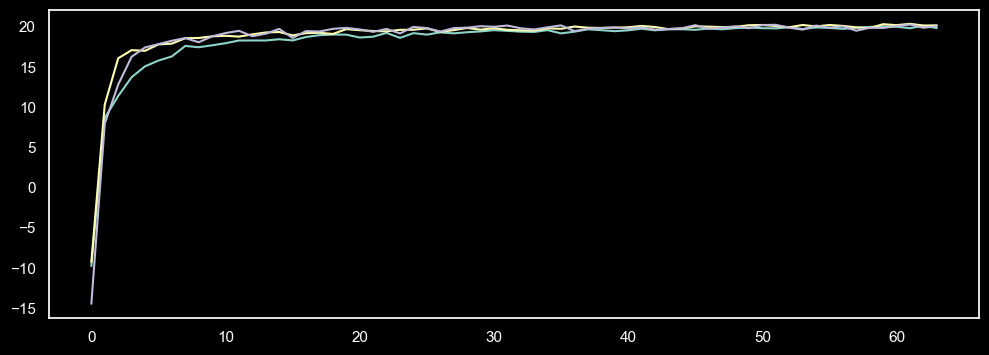

In [10]:
num_samples = 32
plt.figure(figsize=(12, 4))

for nc in [4, 8, 16]:
    pyro.clear_param_store()
    nfml = NFMixtureLikelihood(latent=3, context=10, num_components=nc).cuda()
    mdl = pyro.poutine.scale(nfml.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml.guide, scale=1/batch_size)

    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(loss=elbo[-1])

    plt.plot(elbo)
    print(f'nc={nc}-acc: ', get_test_accuracy(nfml, num_samples=256))

100%|██████████| 64/64 [06:34<00:00,  6.16s/it, loss=39.8]


nc=4-acc:  0.8102


100%|██████████| 64/64 [07:40<00:00,  7.20s/it, loss=40.7]


nc=8-acc:  0.8024


100%|██████████| 64/64 [10:36<00:00,  9.95s/it, loss=41]  


nc=16-acc:  0.8136


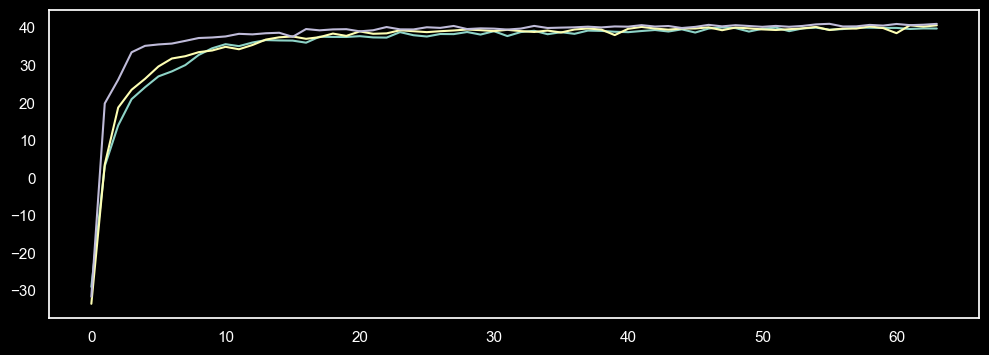

In [11]:
num_samples = 64
plt.figure(figsize=(12, 4))

for nc in [4, 8, 16]:
    pyro.clear_param_store()
    nfml = NFMixtureLikelihood(latent=3, context=10, num_components=nc).cuda()
    mdl = pyro.poutine.scale(nfml.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml.guide, scale=1/batch_size)

    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(loss=elbo[-1])

    plt.plot(elbo)
    print(f'nc={nc}-acc: ', get_test_accuracy(nfml, num_samples=256))

100%|██████████| 64/64 [07:42<00:00,  7.22s/it, loss=79.6]


nc=4-acc:  0.7979


100%|██████████| 64/64 [11:24<00:00, 10.69s/it, loss=81]  


nc=8-acc:  0.8118


100%|██████████| 64/64 [21:13<00:00, 19.89s/it, loss=80.2]


nc=16-acc:  0.8075


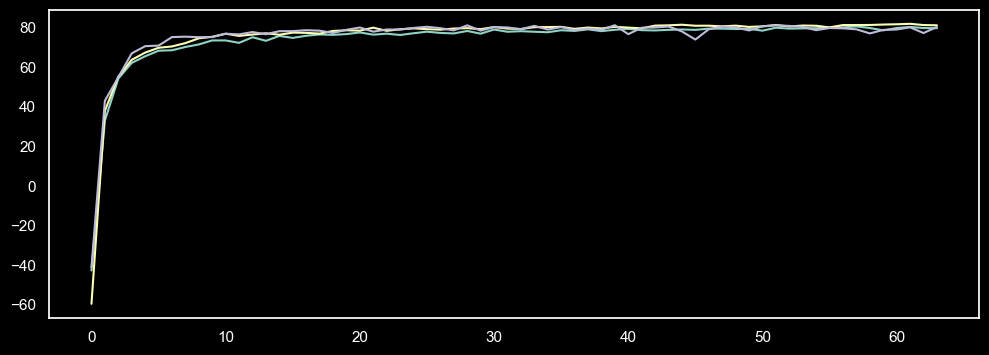

In [12]:
num_samples = 128
plt.figure(figsize=(12, 4))

for nc in [4, 8, 16]:
    pyro.clear_param_store()
    nfml = NFMixtureLikelihood(latent=3, context=10, num_components=nc).cuda()
    mdl = pyro.poutine.scale(nfml.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml.guide, scale=1/batch_size)

    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(loss=elbo[-1])

    plt.plot(elbo)
    print(f'nc={nc}-acc: ', get_test_accuracy(nfml, num_samples=256))

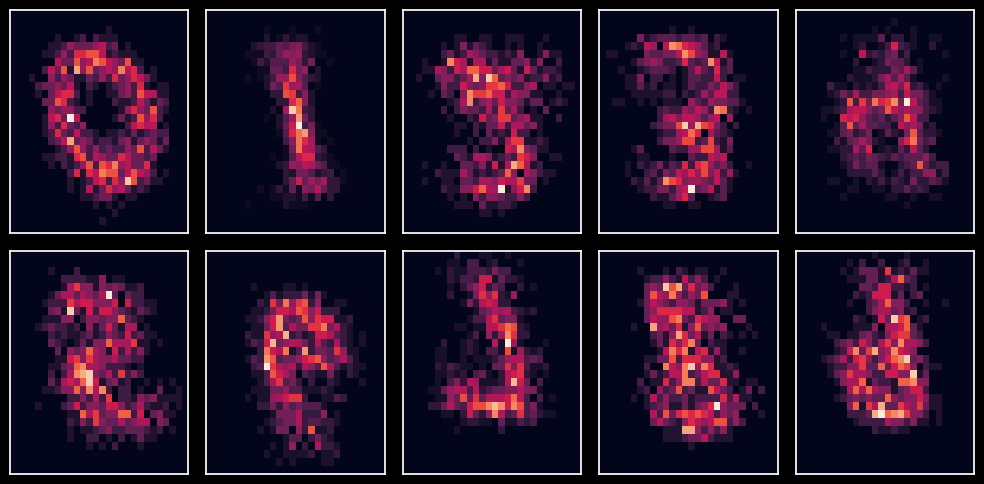

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()
for i, c in enumerate(one_hot(torch.arange(10), 10).float()):
    x = nfml.sample(c.cuda(), 1024).cpu().numpy().squeeze()
    axes[i].hist2d(x[:, 1], x[:, 0], bins=28, range=((-1, 1), (-1, 1)))
    axes[i].set_yticks([])
    axes[i].set_xticks([])

fig.tight_layout()

In [15]:
for ns in [32, 64, 128, 256, 512]:
    print(ns, get_test_accuracy(nfml, num_samples=ns))

32 0.7454
64 0.7763
128 0.7971
256 0.8062
512 0.8119


In [13]:
from pyro.infer import Predictive
def get_test_accuracy_vae(model, prior, guide, num_samples=256):
    comps = []
    pred = Predictive(prior, guide=guide, num_samples=1)
    for x, l in testloader:
        log_evidence = []
        pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
        for c in one_hot(torch.arange(10), 10).cuda().float():
            with torch.no_grad():
                _c = c[None, None].tile(len(x), 1, 1)
                inp = torch.cat([pointcloud.reshape(len(x), -1), _c.squeeze((-3, -2))], dim=-1)
                z = pred(pointcloud, _c)['z'][0]
                log_prob = model.prior(c[None]).log_prob(z) - model.encoder_what(inp).log_prob(z)
                log_prob = log_prob.cpu() + model.log_prob(pointcloud, z, _c).cpu()
                log_evidence.append(log_prob)
        prob = softmax(torch.stack(log_evidence, dim=-1), dim=-1)
        comps.append(prob.argmax(-1) == l)

    return torch.cat(comps).numpy().mean()

In [ ]:
plt.figure(figsize=(12, 4))
num_samples = 32
nc = 1
for latent_dim in [1, 2, 3, 4, 6, 12]:
    pyro.clear_param_store()
    nfml_vae = VAENFML(num_samples, latent_dim=latent_dim, context=10, num_components=nc).cuda()

    mdl = pyro.poutine.scale(nfml_vae.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml_vae.guide, scale=1/batch_size)
    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(elbo=elbo[-1])

    plt.plot(elbo)
    print(f'ld={latent_dim} ', get_test_accuracy_vae(nfml_vae, mdl, gd, num_samples=num_samples))

  0%|          | 0/64 [00:00<?, ?it/s]

100%|██████████| 64/64 [08:41<00:00,  8.15s/it, elbo=17.7] 


ld=1  0.6425


100%|██████████| 64/64 [08:59<00:00,  8.43s/it, elbo=23]   


ld=2  0.7518


100%|██████████| 64/64 [09:02<00:00,  8.47s/it, elbo=18.2]


ld=3  0.6983


100%|██████████| 64/64 [09:03<00:00,  8.49s/it, elbo=23.8]


ld=4  0.7686


100%|██████████| 64/64 [08:58<00:00,  8.42s/it, elbo=23.4] 


ld=6  0.7247


 33%|███▎      | 21/64 [02:52<06:00,  8.39s/it, elbo=16]    

  0%|          | 0/64 [00:00<?, ?it/s]

100%|██████████| 64/64 [09:05<00:00,  8.53s/it, elbo=24.7]


hidden=1  0.7828


100%|██████████| 64/64 [08:54<00:00,  8.35s/it, elbo=26]  


hidden=2  0.8122


100%|██████████| 64/64 [08:22<00:00,  7.86s/it, elbo=26.6]


hidden=3  0.8203


100%|██████████| 64/64 [08:18<00:00,  7.79s/it, elbo=26.3]


hidden=4  0.8134


100%|██████████| 64/64 [08:25<00:00,  7.90s/it, elbo=26.3]


hidden=6  0.8089


100%|██████████| 64/64 [08:18<00:00,  7.79s/it, elbo=26.4]


hidden=12  0.8184


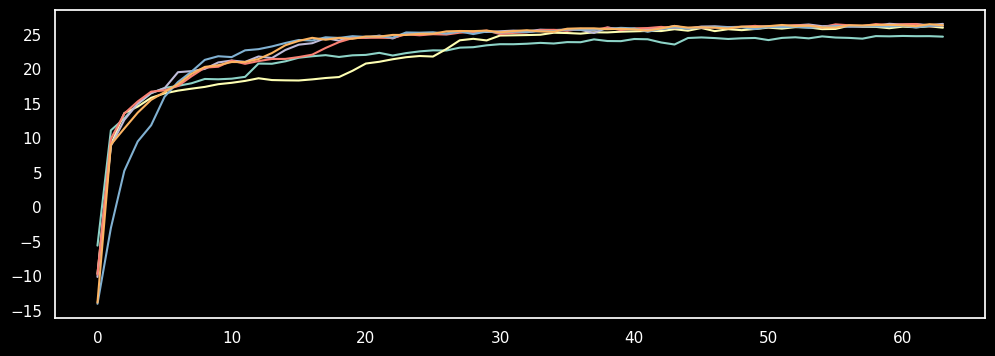

In [ ]:
plt.figure(figsize=(12, 4))
num_samples = 32
nc = 4
for latent_dim in [1, 2, 3, 4, 6, 12]:
    pyro.clear_param_store()
    nfml_vae = VAENFML(num_samples, latent_dim=latent_dim, context=10, num_components=nc).cuda()

    mdl = pyro.poutine.scale(nfml_vae.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml_vae.guide, scale=1/batch_size)
    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(elbo=elbo[-1])

    plt.plot(elbo)
    print(f'latent_dim={latent_dim} ', get_test_accuracy_vae(nfml_vae, mdl, gd, num_samples=num_samples))

In [ ]:
plt.figure(figsize=(12, 4))
num_samples = 128
for nc in [1, 2, 4]:
    pyro.clear_param_store()
    nfml_vae = VAENFML(num_samples, latent=3, context=10, latent_dim=2, num_components=nc).cuda()

    mdl = pyro.poutine.scale(nfml_vae.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml_vae.guide, scale=1/batch_size)
    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(elbo=elbo[-1])

    plt.plot(elbo)
    print(f'nc={nc} ', get_test_accuracy_vae(nfml_vae, mdl, gd, num_samples=num_samples))

  0%|          | 0/64 [00:00<?, ?it/s]

100%|██████████| 64/64 [08:51<00:00,  8.30s/it, elbo=101] 


nc=1  0.8129


100%|██████████| 64/64 [09:35<00:00,  8.99s/it, elbo=112] 


nc=2  0.8589


100%|██████████| 64/64 [11:07<00:00, 10.42s/it, elbo=115]


nc=4  0.8723


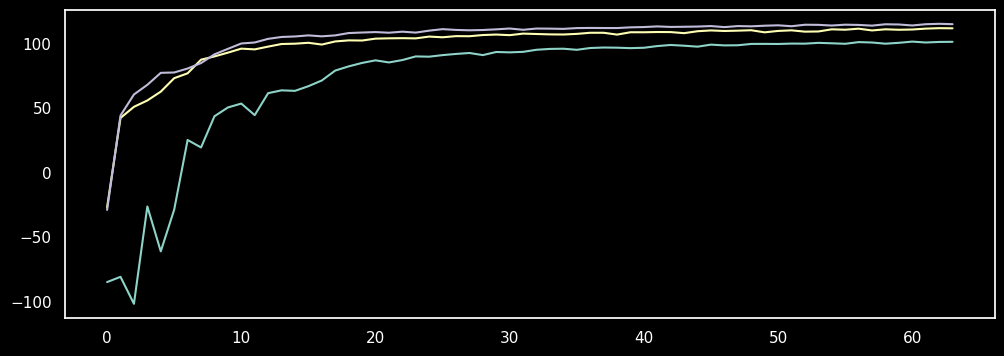

In [15]:
plt.figure(figsize=(12, 4))
num_samples = 128
for nc in [1, 2, 4]:
    pyro.clear_param_store()
    nfml_vae = VAENFML(num_samples, latent=3, context=10, hidden=2, num_components=nc).cuda()

    mdl = pyro.poutine.scale(nfml_vae.model, scale=1/batch_size)
    gd = pyro.poutine.scale(nfml_vae.guide, scale=1/batch_size)
    svi = SVI(mdl, gd, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

    elbo = []
    for epoch in (bar := tqdm(range(64))):
        losses = []

        for x, l in trainloader:
            pointcloud = image_to_pointcloud(x.flatten(-3), num_samples=num_samples).cuda()
            context = one_hot(l, 10)[:, None].float().cuda()

            losses.append(svi.step(pointcloud, context))

        losses = torch.tensor(losses)
        elbo.append( - losses.mean().item())
        bar.set_postfix(elbo=elbo[-1])

    plt.plot(elbo)
    print(f'nc={nc} ', get_test_accuracy_vae(nfml_vae, mdl, gd, num_samples=num_samples))

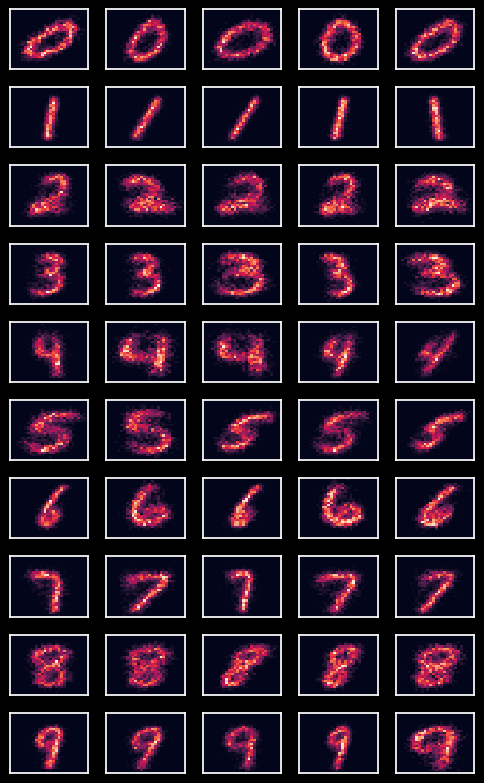

In [18]:
fig, axes = plt.subplots(10, 5, figsize=(5, 8), sharex=True, sharey=True)

for j in range(5):
    for i, c in enumerate(one_hot(torch.arange(10), 10).float()):
        x = nfml_vae.sample(c.cuda(), 2 * 1024).cpu().numpy()
        axes[i, j].hist2d(x[:, 1], -x[:, 0], bins=28, range=((-1, 1), (-1, 1)))
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

fig.tight_layout()